## Hospital Operations and Patient Outcome Analysis
This notebook analyzes synthetic hospital patient records to understand demographic patterns, diagnosis distribution, hospital stay duration, treatment costs, and patient outcomes.

Key questions:
• What diagnoses are most common?

• What factors influence treatment costs?

• How long do patients stay in the hospital?

• How do lifestyle factors (smoking, diabetes) relate to outcomes?

In [1]:
#import the libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
# loading the dataset 
df = pd.read_csv("synthetic_healthcare_data.csv")

In [3]:
#dataset overview
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nData types and non-null counts:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all"))


Shape of dataset: (500, 13)

First 5 rows:


,Patient_ID,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Smoker,Diabetic,Diagnosis,Treatment_Cost,Admission_Date,Discharge_Date,Outcome
0,P001,20,Female,24.7,104 / 72,245,No,Yes,Diabetes,3328.60,2025-01-20,2025-02-01,Recovered
1,P002,47,Male,38.5,147 / 88,268,Yes,No,Diabetes,1041.69,2025-07-01,2025-07-04,Referred
2,P003,21,Male,18.5,145 / 65,199,No,Yes,Hypertension,909.11,2025-06-28,2025-07-06,Referred
3,P004,57,Male,24.1,166 / 66,271,Yes,Yes,Hypertension,1920.12,2025-02-10,2025-02-18,Deceases
4,P005,28,Male,22.5,176 / 71,197,Yes,No,Flu,3224.12,2025-04-18,2025-04-27,Deceases



Last 5 rows:


,Patient_ID,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Smoker,Diabetic,Diagnosis,Treatment_Cost,Admission_Date,Discharge_Date,Outcome
495,P496,59,Male,18.3,161 / 77,269,Yes,No,Heart Disease,1675.74,2025-03-29,2025-04-02,Deceases
496,P497,38,Male,19.6,142 / 97,186,Yes,No,Hypertension,2113.33,2025-07-07,2025-07-17,Referred
497,P498,46,Female,28.6,96 / 100,275,No,No,Heart Disease,4121.19,2024-11-21,2024-12-05,Referred
498,P499,47,Female,29.6,162 / 84,201,No,No,Diabetes,1065.24,2025-05-10,2025-05-15,Deceases
499,P500,85,Male,25.0,134 / 74,237,Yes,Yes,Diabetes,422.94,2025-06-10,2025-06-16,Deceases



Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Patient_ID         500 non-null    object 
 1   Age                500 non-null    int64  
 2   Gender             500 non-null    object 
 3   BMI                500 non-null    float64
 4   Blood_Pressure     500 non-null    object 
 5   Cholesterol_Level  500 non-null    int64  
 6   Smoker             500 non-null    object 
 7   Diabetic           500 non-null    object 
 8   Diagnosis          500 non-null    object 
 9   Treatment_Cost     500 non-null    float64
 10  Admission_Date     500 non-null    object 
 11  Discharge_Date     500 non-null    object 
 12  Outcome            500 non-null    object 
dtypes: float64(2), int64(2), object(9)
memory usage: 50.9+ KB

Summary statistics:


,Patient_ID,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Smoker,Diabetic,Diagnosis,Treatment_Cost,Admission_Date,Discharge_Date,Outcome
count,500,500.000000,500,500.000000,500,500.000000,500,500,500,500.00000,500,500,500
unique,500,NaN,2,NaN,471,NaN,2,2,5,NaN,267,280,3
top,P001,NaN,Female,NaN,140 / 108,NaN,No,Yes,Diabetes,NaN,2025-06-22,2025-01-12,Referred
freq,1,NaN,251,NaN,2,NaN,263,261,115,NaN,5,6,178
mean,NaN,54.140000,NaN,28.770400,NaN,226.544000,NaN,NaN,NaN,2514.42770,NaN,NaN,NaN
std,NaN,21.219069,NaN,6.340034,NaN,43.667491,NaN,NaN,NaN,1379.49882,NaN,NaN,NaN
min,NaN,18.000000,NaN,18.000000,NaN,151.000000,NaN,NaN,NaN,106.04000,NaN,NaN,NaN
25%,NaN,36.000000,NaN,23.475000,NaN,189.750000,NaN,NaN,NaN,1406.10750,NaN,NaN,NaN
50%,NaN,55.000000,NaN,28.500000,NaN,225.500000,NaN,NaN,NaN,2538.01000,NaN,NaN,NaN
75%,NaN,73.000000,NaN,34.200000,NaN,266.000000,NaN,NaN,NaN,3671.94500,NaN,NaN,NaN


In [4]:
df.head()
df.tail()

,Patient_ID,Age,Gender,BMI,Blood_Pressure,Cholesterol_Level,Smoker,Diabetic,Diagnosis,Treatment_Cost,Admission_Date,Discharge_Date,Outcome
495,P496,59,Male,18.3,161 / 77,269,Yes,No,Heart Disease,1675.74,2025-03-29,2025-04-02,Deceases
496,P497,38,Male,19.6,142 / 97,186,Yes,No,Hypertension,2113.33,2025-07-07,2025-07-17,Referred
497,P498,46,Female,28.6,96 / 100,275,No,No,Heart Disease,4121.19,2024-11-21,2024-12-05,Referred
498,P499,47,Female,29.6,162 / 84,201,No,No,Diabetes,1065.24,2025-05-10,2025-05-15,Deceases
499,P500,85,Male,25.0,134 / 74,237,Yes,Yes,Diabetes,422.94,2025-06-10,2025-06-16,Deceases


In [5]:
#Checking for missing values 
missing_values = df.isnull().sum().sort_values(ascending=False)
print("\nMissing values by column:")
display(missing_values)

missing_nonzero = missing_values[missing_values > 0]

if len(missing_nonzero) > 0:
    plt.figure(figsize=(10, 4))
    missing_nonzero.plot(kind="bar")
    plt.title("Missing Values by Feature")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")



Missing values by column:


Patient_ID           0
Age                  0
Gender               0
BMI                  0
Blood_Pressure       0
Cholesterol_Level    0
Smoker               0
Diabetic             0
Diagnosis            0
Treatment_Cost       0
Admission_Date       0
Discharge_Date       0
Outcome              0
dtype: int64

No missing values found.


In [6]:
#data cleaning and feature engineering 
# Convert dates
df["Admission_Date"] = pd.to_datetime(df["Admission_Date"], errors="coerce")
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"], errors="coerce")

# Check for invalid dates
print("Missing Admission_Date after conversion:", df["Admission_Date"].isnull().sum())
print("Missing Discharge_Date after conversion:", df["Discharge_Date"].isnull().sum())

# Length of stay in days
df["stay_length"] = (df["Discharge_Date"] - df["Admission_Date"]).dt.days

print("\nSummary of stay length:")
display(df["stay_length"].describe())

# Check for impossible date ordering
invalid_stays = (df["Discharge_Date"] < df["Admission_Date"]).sum()
print("Number of rows where discharge date is before admission date:", invalid_stays)

# Split blood pressure into systolic and diastolic
bp_split = df["Blood_Pressure"].astype(str).str.split("/", expand=True)

df["Systolic_BP"] = pd.to_numeric(bp_split[0].str.strip(), errors="coerce")
df["Diastolic_BP"] = pd.to_numeric(bp_split[1].str.strip(), errors="coerce")

print("\nBlood pressure columns created:")
display(df[["Blood_Pressure", "Systolic_BP", "Diastolic_BP"]].head())

# Create age groups
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 35, 50, 65, 120],
    labels=["0-18", "19-35", "36-50", "51-65", "65+"],
    include_lowest=True
)

# Standardize outcome spelling if needed
# Some datasets use "Deceases" instead of "Deceased"
df["Outcome"] = df["Outcome"].replace({
    "Deceases": "Deceased",
    "deceases": "Deceased",
    "deceased": "Deceased"
})

print("\nUnique outcomes:")
print(df["Outcome"].unique())

Missing Admission_Date after conversion: 0
Missing Discharge_Date after conversion: 0

Summary of stay length:


count    500.000000
mean       7.264000
std        4.065385
min        1.000000
25%        4.000000
50%        7.000000
75%       11.000000
max       14.000000
Name: stay_length, dtype: float64

Number of rows where discharge date is before admission date: 0

Blood pressure columns created:


,Blood_Pressure,Systolic_BP,Diastolic_BP
0,104 / 72,104,72
1,147 / 88,147,88
2,145 / 65,145,65
3,166 / 66,166,66
4,176 / 71,176,71



Unique outcomes:
['Recovered' 'Referred' 'Deceased']


## Exploratory Data Analysis 


Diagnosis counts:


Diagnosis
Diabetes         115
Hypertension     106
Pneumonia        104
Heart Disease     90
Flu               85
Name: count, dtype: int64

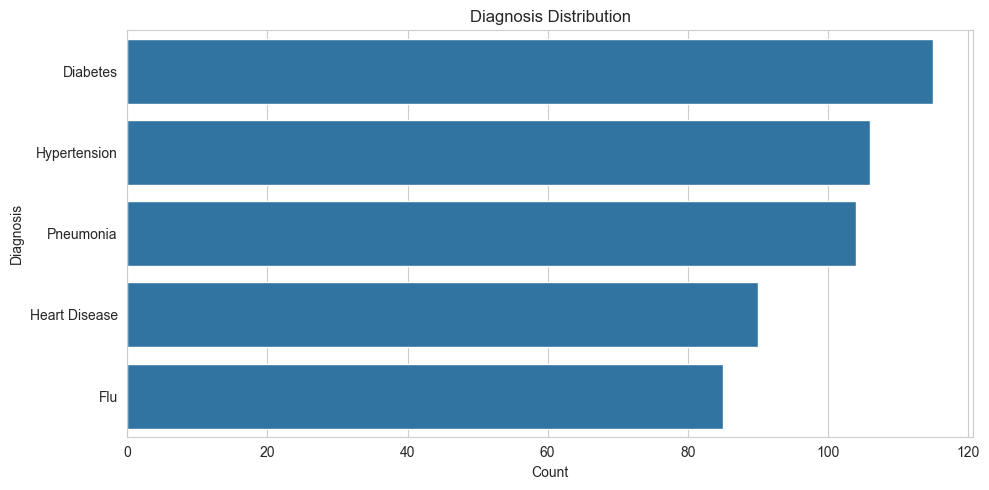

In [7]:
#diagnosis analysis 
print("\nDiagnosis counts:")
display(df["Diagnosis"].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(y="Diagnosis", data=df, order=df["Diagnosis"].value_counts().index)
plt.title("Diagnosis Distribution")
plt.xlabel("Count")
plt.ylabel("Diagnosis")
plt.tight_layout()
plt.show()


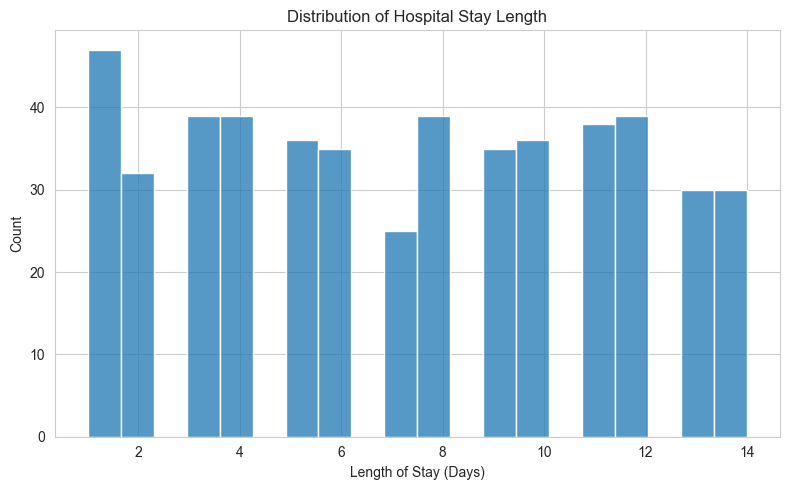

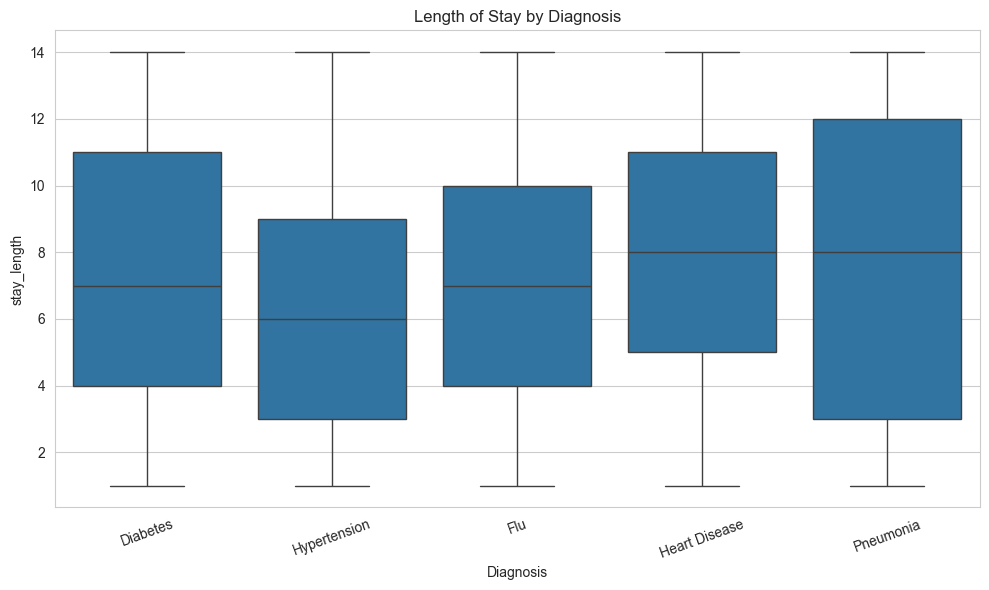

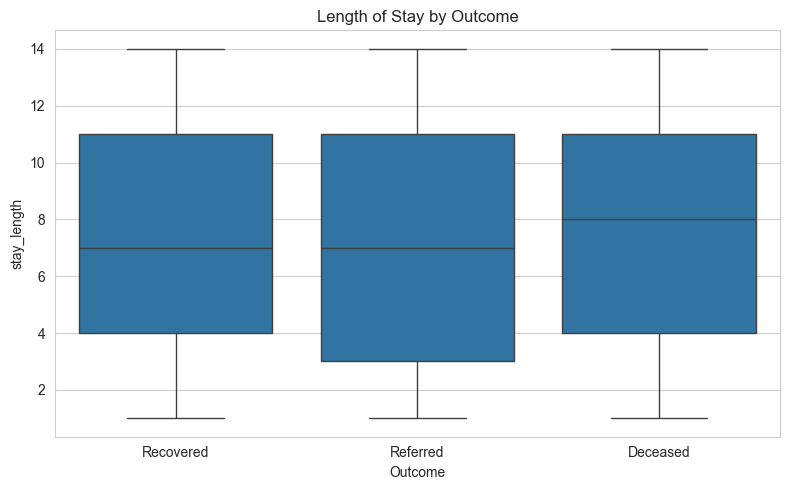


Average stay length by diagnosis:


Diagnosis
Heart Disease    7.866667
Diabetes         7.660870
Pneumonia        7.615385
Flu              6.917647
Hypertension     6.254717
Name: stay_length, dtype: float64


Average stay length by outcome:


Outcome
Deceased     7.368098
Referred     7.230337
Recovered    7.194969
Name: stay_length, dtype: float64

In [8]:
#length of stay analysis 
plt.figure(figsize=(8, 5))
sns.histplot(df["stay_length"].dropna(), bins=20)
plt.title("Distribution of Hospital Stay Length")
plt.xlabel("Length of Stay (Days)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x="Diagnosis", y="stay_length", data=df)
plt.title("Length of Stay by Diagnosis")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="Outcome", y="stay_length", data=df)
plt.title("Length of Stay by Outcome")
plt.tight_layout()
plt.show()

print("\nAverage stay length by diagnosis:")
display(df.groupby("Diagnosis")["stay_length"].mean().sort_values(ascending=False))

print("\nAverage stay length by outcome:")
display(df.groupby("Outcome")["stay_length"].mean().sort_values(ascending=False))

Hospital stay length is calculated as the difference between discharge and admission date in days.

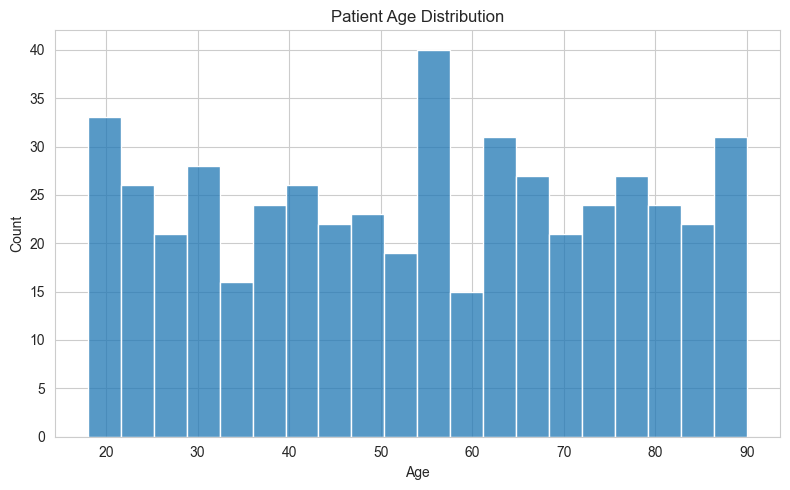

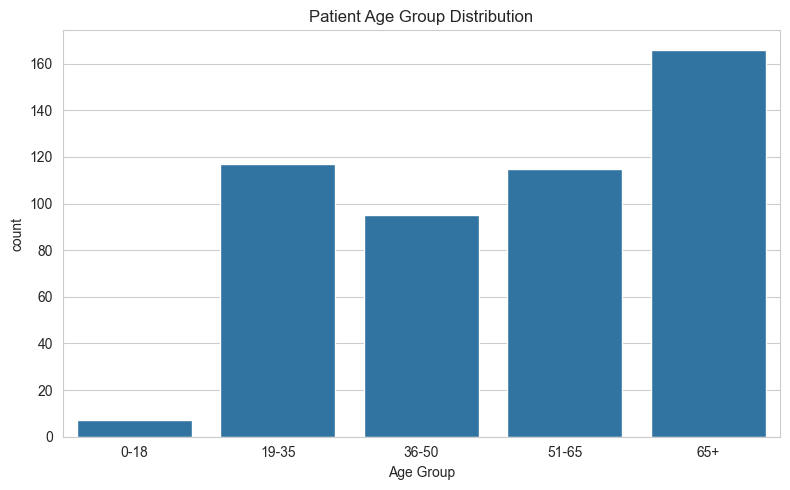

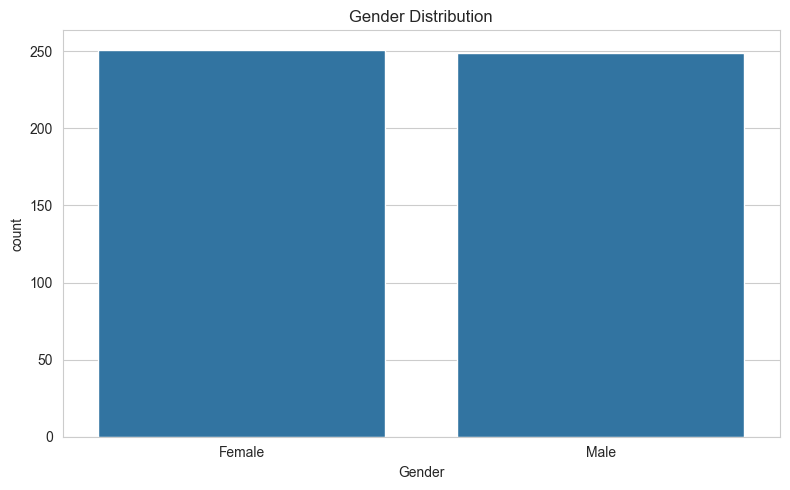

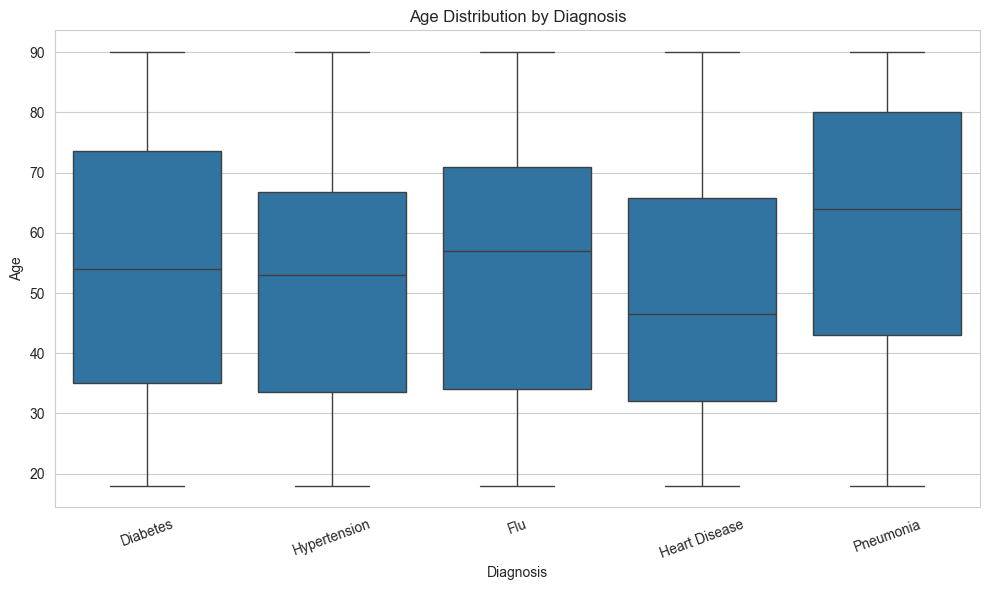

In [9]:
#demographic analysis  
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=20)
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x="Age_Group", data=df, order=["0-18", "19-35", "36-50", "51-65", "65+"])
plt.title("Patient Age Group Distribution")
plt.xlabel("Age Group")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x="Diagnosis", y="Age", data=df)
plt.title("Age Distribution by Diagnosis")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


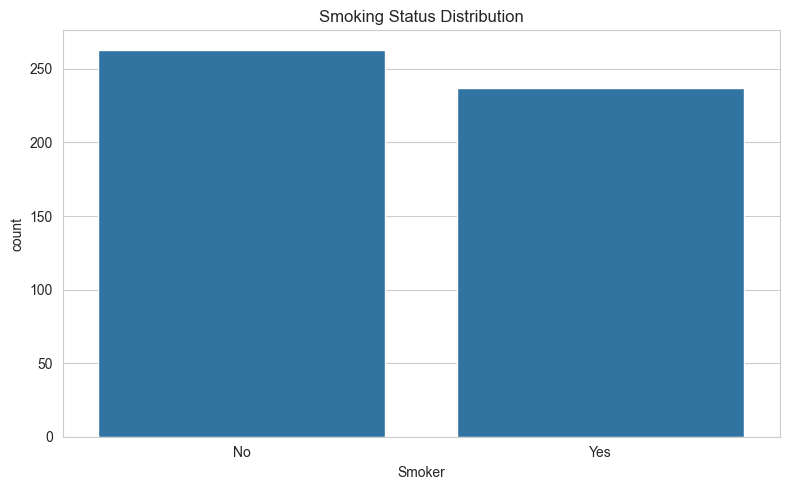

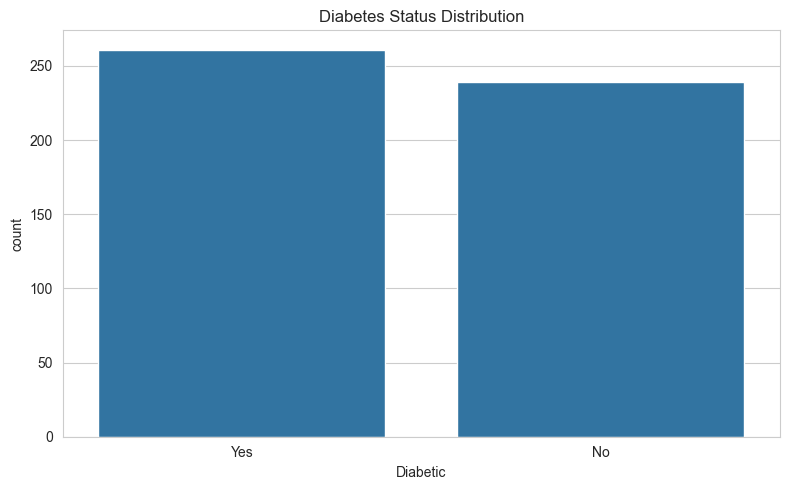

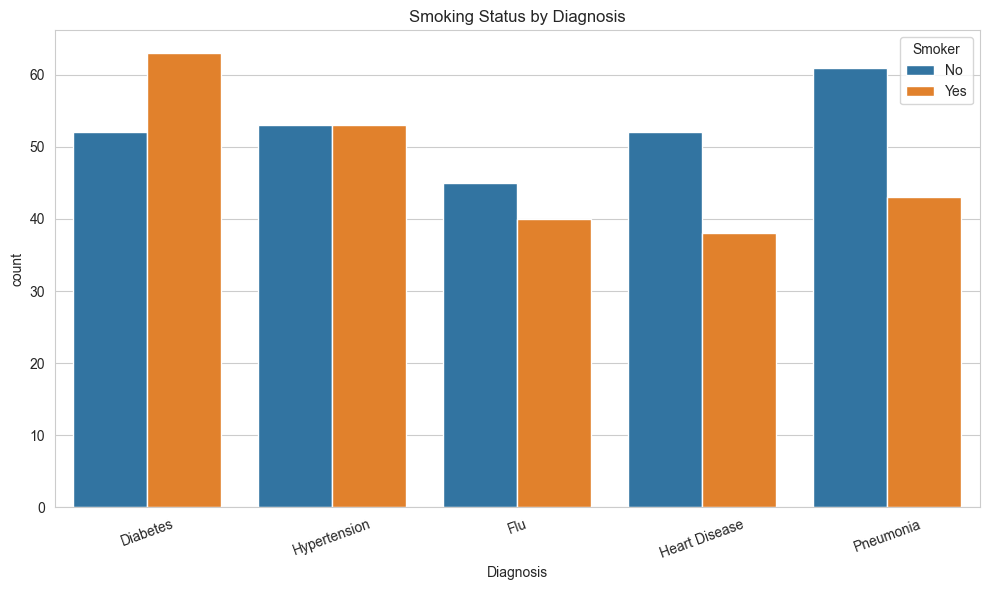

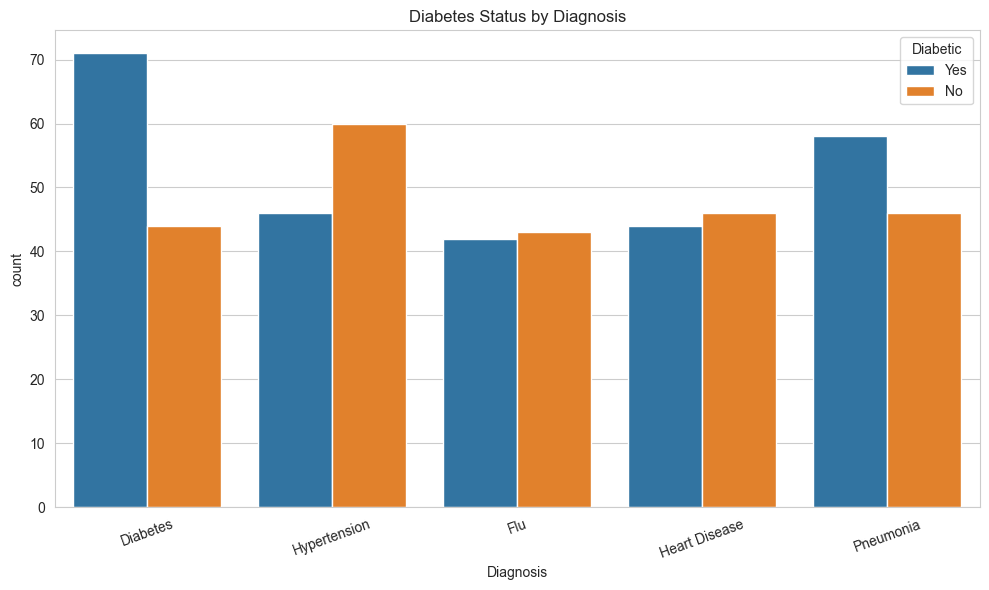

In [10]:
#life risk factor analysis
plt.figure(figsize=(8, 5))
sns.countplot(x="Smoker", data=df)
plt.title("Smoking Status Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x="Diabetic", data=df)
plt.title("Diabetes Status Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x="Diagnosis", hue="Smoker", data=df)
plt.title("Smoking Status by Diagnosis")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x="Diagnosis", hue="Diabetic", data=df)
plt.title("Diabetes Status by Diagnosis")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

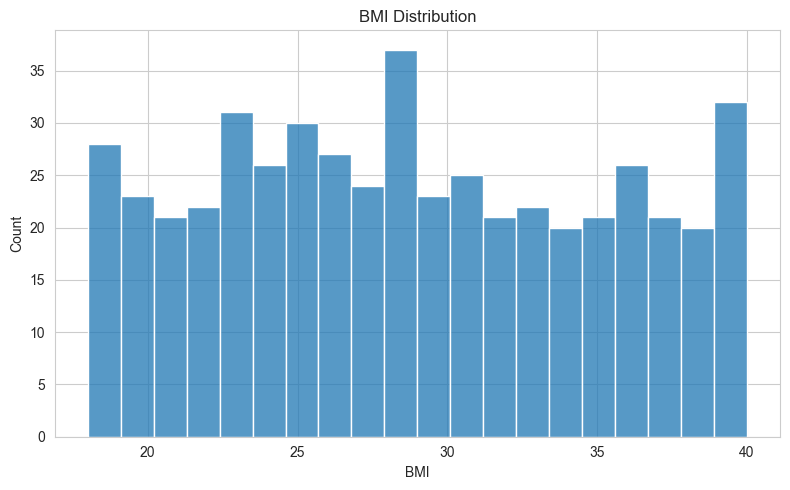

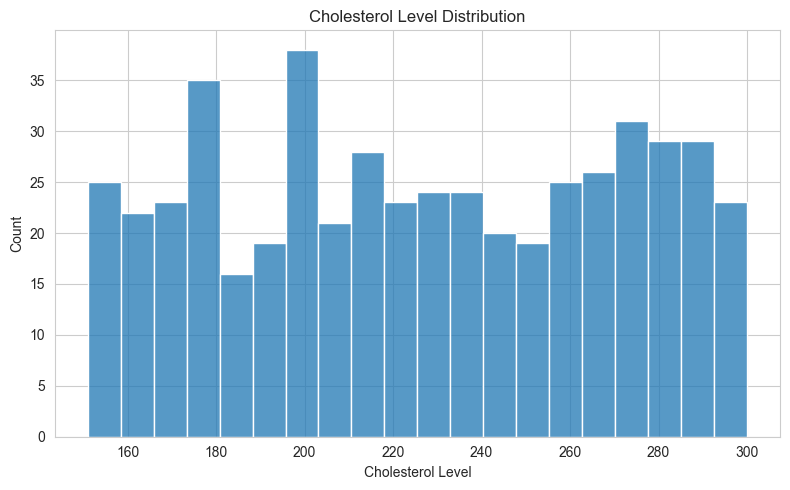

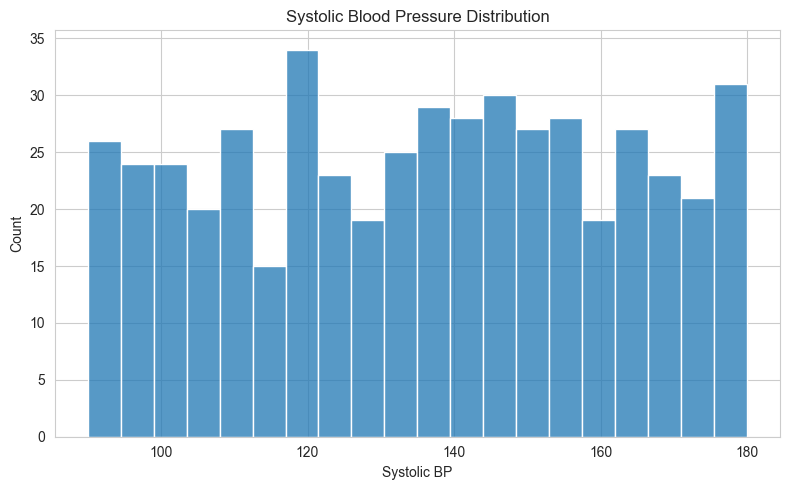

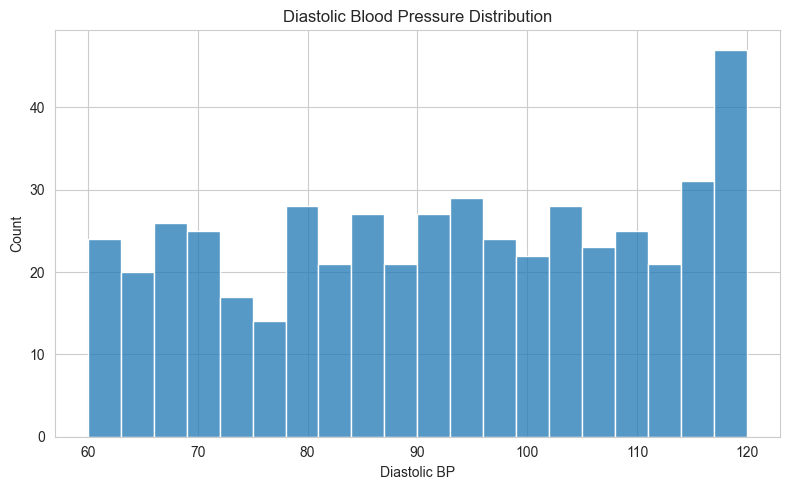

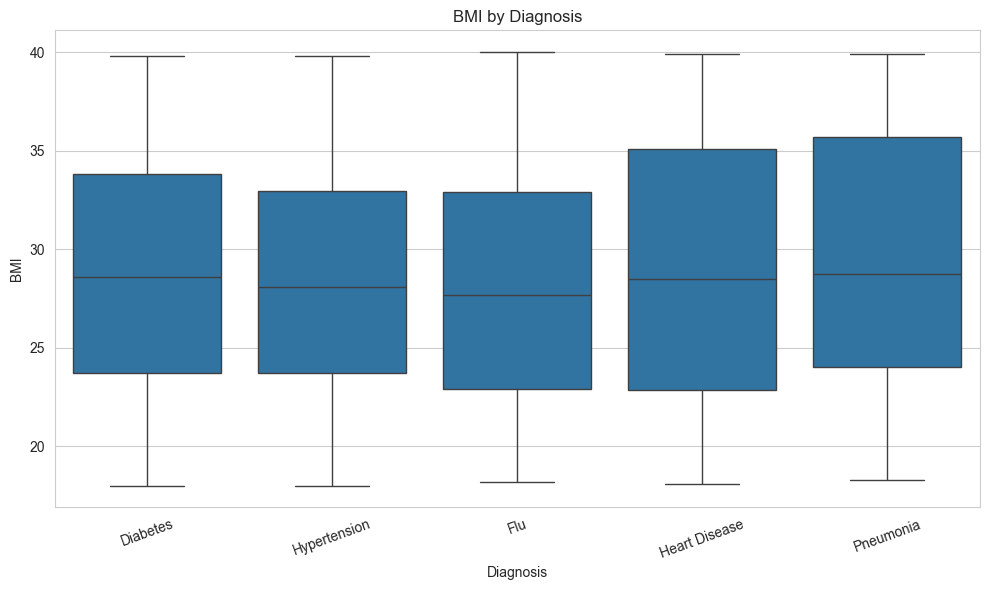

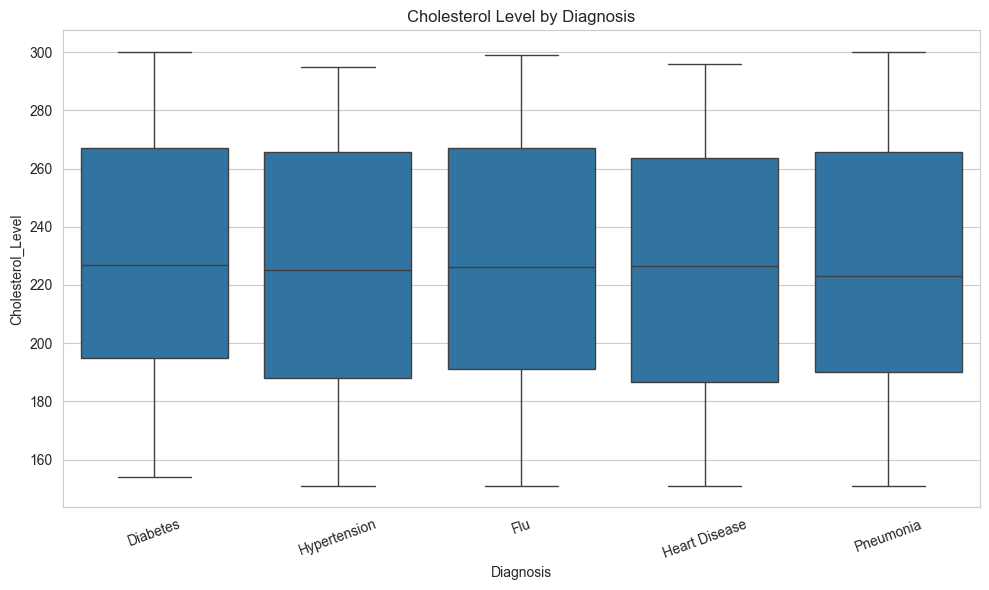

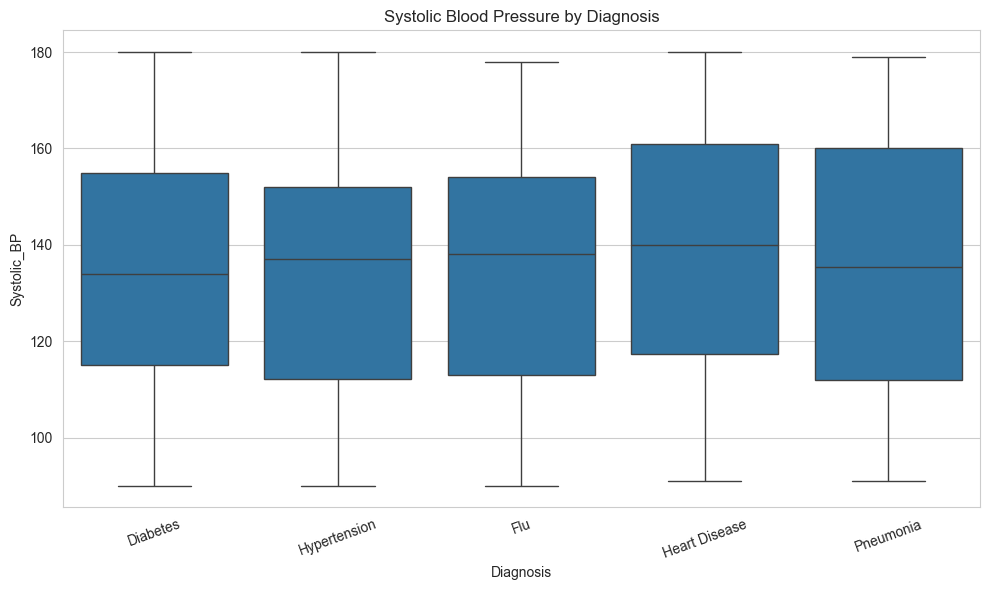

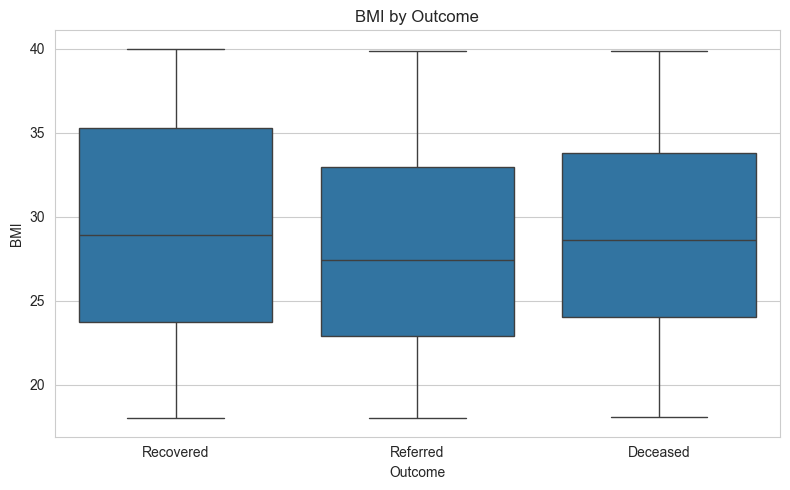

In [11]:
 #health metric analysis
plt.figure(figsize=(8, 5))
sns.histplot(df["BMI"], bins=20)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["Cholesterol_Level"], bins=20)
plt.title("Cholesterol Level Distribution")
plt.xlabel("Cholesterol Level")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["Systolic_BP"], bins=20)
plt.title("Systolic Blood Pressure Distribution")
plt.xlabel("Systolic BP")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["Diastolic_BP"], bins=20)
plt.title("Diastolic Blood Pressure Distribution")
plt.xlabel("Diastolic BP")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x="Diagnosis", y="BMI", data=df)
plt.title("BMI by Diagnosis")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x="Diagnosis", y="Cholesterol_Level", data=df)
plt.title("Cholesterol Level by Diagnosis")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x="Diagnosis", y="Systolic_BP", data=df)
plt.title("Systolic Blood Pressure by Diagnosis")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x="Outcome", y="BMI", data=df)
plt.title("BMI by Outcome")
plt.tight_layout()
plt.show()

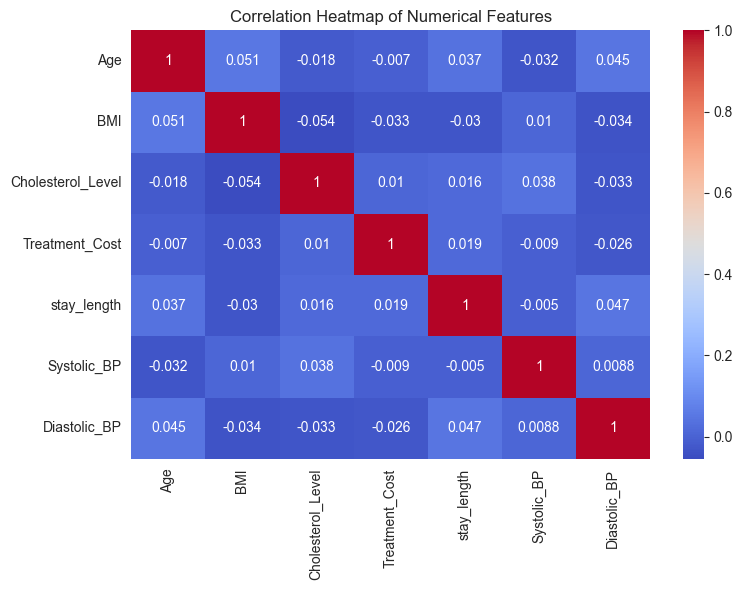

In [12]:
#correlation heatmap
numeric_cols = [
    "Age", "BMI", "Cholesterol_Level", "Treatment_Cost",
    "stay_length", "Systolic_BP", "Diastolic_BP"
]

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


## Predictive Modelling 

Goal: predict Treatment_Cost using clinical + demographic + operational features

In [13]:
model_df = df.copy()

features = [
    "Age", "Gender", "BMI", "Cholesterol_Level",
    "Smoker", "Diabetic", "Diagnosis", "Outcome",
    "stay_length", "Systolic_BP", "Diastolic_BP"
]

target = "Treatment_Cost"

X = model_df[features]
y = model_df[target]

categorical_features = ["Gender", "Smoker", "Diabetic", "Diagnosis", "Outcome"]
numeric_features = ["Age", "BMI", "Cholesterol_Level", "stay_length", "Systolic_BP", "Diastolic_BP"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

regressor = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", regressor)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("Model Performance:")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R^2 :", round(r2, 4))

Model Performance:
MAE : 1258.22
RMSE: 1464.49
R^2 : -0.0246


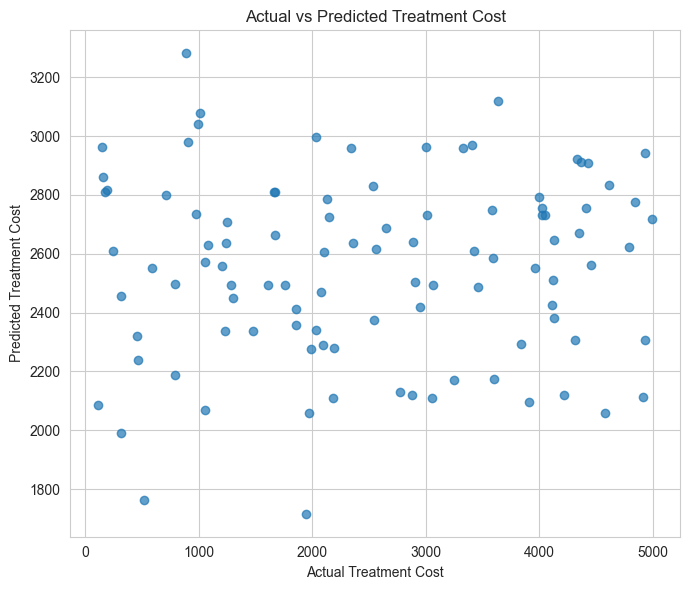

In [14]:
# Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, preds, alpha=0.7)
plt.xlabel("Actual Treatment Cost")
plt.ylabel("Predicted Treatment Cost")
plt.title("Actual vs Predicted Treatment Cost")
plt.tight_layout()
plt.show()

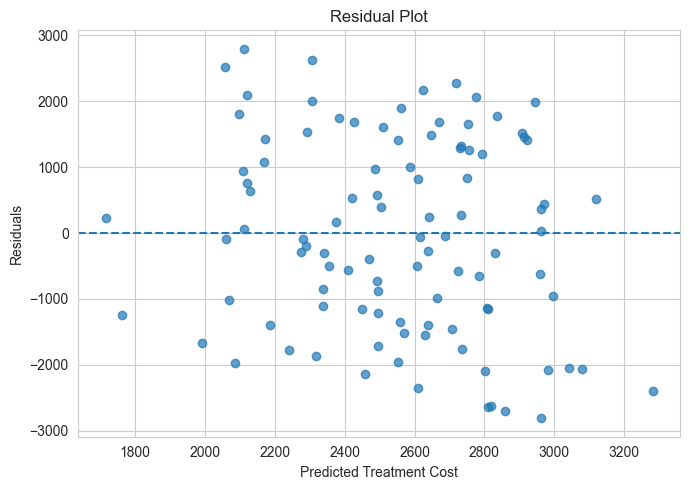

In [15]:
# Residual Plot
residuals = y_test - preds

plt.figure(figsize=(7, 5))
plt.scatter(preds, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Treatment Cost")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()


Top 15 Most Important Features:


,Feature,Importance
1,BMI,0.165568
2,Cholesterol_Level,0.158188
5,Diastolic_BP,0.139236
0,Age,0.137245
4,Systolic_BP,0.135533
3,stay_length,0.086205
18,Outcome_Recovered,0.018258
12,Diagnosis_Diabetes,0.015278
14,Diagnosis_Heart Disease,0.014854
17,Outcome_Deceased,0.014847


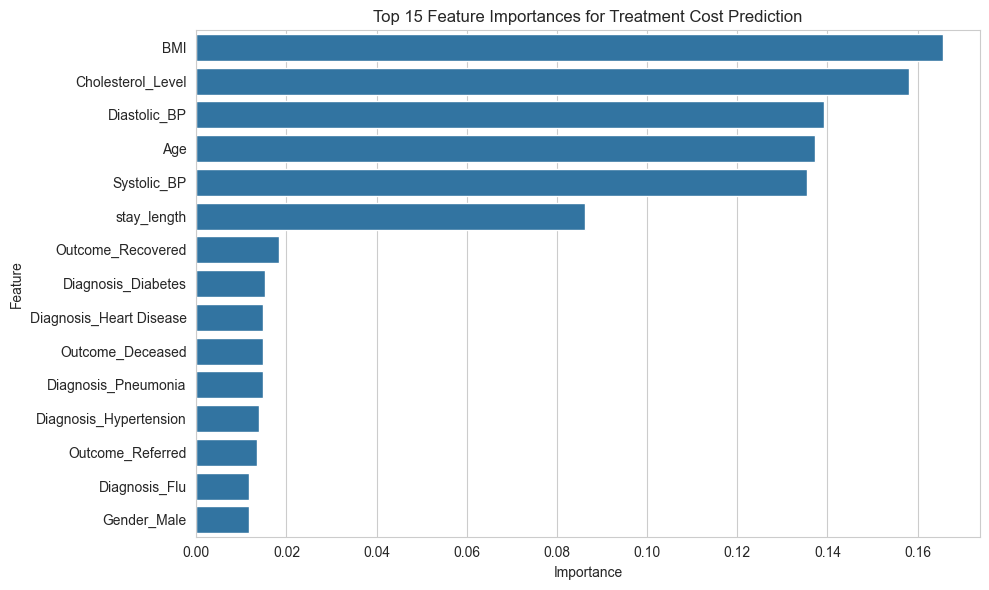

In [16]:
# Feature Importance
# Get transformed feature names
ohe = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names = ohe.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": model.named_steps["regressor"].feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 15 Most Important Features:")
display(feature_importance.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances for Treatment Cost Prediction")
plt.tight_layout()
plt.show()


## Key Insights 


1. Hospital stay length is an important operational variable and may be linked to higher treatment costs.
2. Diagnosis categories differ in both median stay length and treatment cost.
3. Smoking, diabetes, cholesterol, and blood pressure provide useful clinical context for patient outcomes and cost patterns.
4. Blood pressure feature engineering (systolic/diastolic) adds more analytical value than keeping the original text field.
5. The treatment cost model provides a stronger portfolio component by showing both EDA and predictive analytics.
